----
## <font color='CornflowerBlue'>Practical 2: Constructing, Training & Evaluating Neural Networks 
##### Alok Bharadwaj and Arjen Jakobi
---

<!--- Recognize that images have spatial structure (locality + translation equivariance)
(What is a good way to show this?)
- Understand the convolution operation
(1-D and 2-D operations)
- Show how convolution kernels can learn spatial structure
(Edge detection, design your own kernel etc)
- See empirically that a CNN learns from less data than an FC for image tasks
(Use the same MNIST data for CNN or use CIFAR for more complex images)
- Show kernels that are learned by the CNN and connect to the spatial structure of the data
https://poloclub.github.io/cnn-explainer/
- Connect to inductive bias from Module 1
-->

## Module 2: Convolutional Neural Networks

In last week's practical, we worked with fully connected neural networks and saw how they can learn complex functions from data. In the previous module, we applied fully connected neural networks (FCNs) to image data. While your model was able to learn from the data, you also found that it treated images simply as long vectors of pixel values and ignored the underlying spatial structure.

Images are not just collections of independent pixels—they contain local patterns such as edges, textures, and shapes, and these patterns can appear in different locations within the image. A key challenge is therefore to design models that can efficiently capture this locality and **translation equivariance** (i.e., the ability to recognize the same pattern regardless of where it appears).

In this module, we introduce **convolutional neural networks (CNNs)**, which are particularly useful to exploit the structure of image data. We will begin by understanding what an image is in terms of arrays of pixel values, and how meaningful structures can be inferred from them. We will then introduce the **convolution operation**, first in one dimension and then in two dimensions, and explore how simple kernels can detect features such as edges.

Building on this, you will see how convolutional kernels can be learned directly from data, and how CNNs provide a powerful **inductive bias** that allows them to learn more efficiently than fully connected networks on image tasks. Finally, we will visualise the learned filters and connect them back to the spatial structure present in the data.

Before moving on to CNNs, we will first have a closer look at the data structure of images and at convolution operations.

### 1. What is an image to a computer?

<!--
- Show how image is a 2D array of pixel values (grayscale) or a 3D array (color images with RGB channels).
- What structures can you see from the image (horizontal edge, corners, stripies etc)? How can you tell these structures from the pixel values alone?
-->

Before introducing convolutional neural networks, we first need to understand what an image is from a numerical perspective.

An image is simply an **array of pixel values**:
- A grayscale image is a 2D array of shape `[H, W]`, where each pixel is a single intensity value  
- A color image is a 3D array of shape `[H, W, 3]`, where each pixel consists of three values corresponding to the <font color='red'>red</font>, <font color='green'>green</font> and <font color='blue'> blue</font> (RGB) channels  

Although we perceive images as objects, edges, and textures, a computer only sees numbers arranged on a grid.

#### A grayscale image represents pixels as intensity values

In the first example, we visualise a grayscale image and zoom into a small region. This will allow us to see that:
- Each pixel corresponds to a single number  
- Smooth regions have similar values  
- Sharp changes in values correspond to edges  

Try to identify where the image changes abruptly. Can you relate these changes to structures such as edges or boundaries in the image? You can use the x,y sliders to move the zoom box across the image.

In [ ]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from src.conv_utils import get_pixel_values
I = resize(data.camera(), (256, 256), anti_aliasing=True)
# --- Interactive pixel inspector ---
ui = get_pixel_values(I, box=8);
display(ui)

#### A color image represents each pixel using multiple channels

In the second example, we look at a color image and its individual RGB channels. Each channel can be thought of as a separate 2D image capturing a different aspect of the scene.

By visualising the channels and zooming into a small patch, you can observe that:
- Each pixel is now a vector of three values  
- Different channels highlight different structures  
- Local patterns (edges, textures) are still present, but distributed across channels  


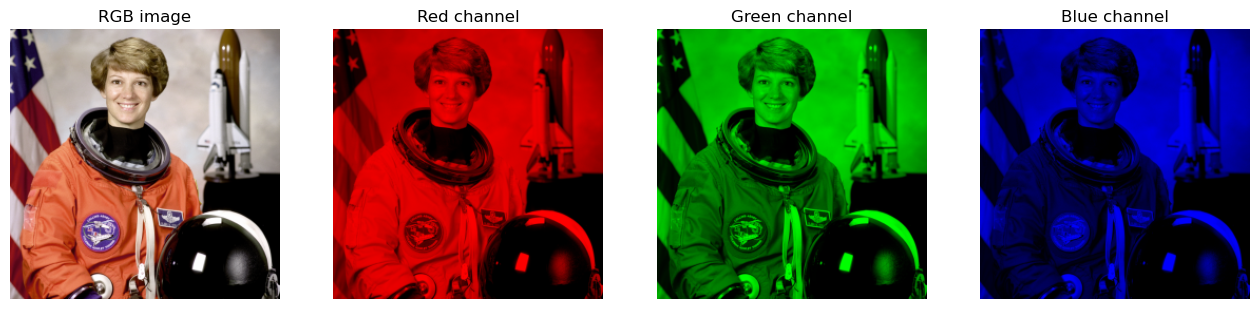

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from src.conv_utils import get_pixel_values
from IPython.display import display

# Load and resize image
I = resize(data.astronaut(), (256, 256), anti_aliasing=True)

# --- Create colored channel images ---
R = np.zeros_like(I)
G = np.zeros_like(I)
B = np.zeros_like(I)

R[:, :, 0] = I[:, :, 0]
G[:, :, 1] = I[:, :, 1]
B[:, :, 2] = I[:, :, 2]

# --- Plot original + channels ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

# Original image and channels in RGB
axs[0].imshow(I)
axs[0].set_title("RGB image")
axs[0].axis("off")

axs[1].imshow(R)
axs[1].set_title("Red channel")
axs[1].axis("off")

axs[2].imshow(G)
axs[2].set_title("Green channel")
axs[2].axis("off")

axs[3].imshow(B)
axs[3].set_title("Blue channel")
axs[3].axis("off")

plt.show()

# --- Interactive pixel inspector ---
ui = get_pixel_values(I[:, :, 0], box=8)  # red channel
display(ui)

### 2. What is convolution?

Convolution is a mathematical operation that describes how one function is <u>combined with</u> or <u>filtered by</u> another function. Intuitively, it measures how well a certain pattern matches a signal as it is shifted across it.

The continuous definition of convolution is given by:

\begin{equation}
    (f \circledast g)(y) = \int_{-\infty}^{\infty} f(x)\,g(y - x)\,dx
\end{equation}

where $f$ and $g$ are two functions, and $\circledast$ denotes the convolution operator.

We will develop an intuitive understanding of convolution through simple examples:

- **1D convolution**: visualise convolution as a sliding operation 
- **2D convolution**: apply filters (kernels) to images to extract or highlight structures such as edges, lines, and textures  

You will also experiment with designing your own kernels and observe how different filters highlight different features in the data. Let's first look at the convolution of two 1D functions.

In [ ]:
### setup
from src.conv_utils import (
    play_with_convolution_illustration,
)

play_with_convolution_illustration();


In practice, we typically work with discrete data. For example, images are grids of pixel values, not continuous functions. Convolution is therefore implemented as a sum:

\begin{equation}
(I \circledast K)[i, j] = \sum_{m} \sum_{n} I[i - m, j - n] \, K[m, n]
\end{equation}

where $I$ is the image and $K$ is a small matrix called a **kernel** or **filter**

For images, convolution can be understood as a **sliding window operation**:

- A small kernel is placed on top of the image  
- It is moved across the image  
- At each position, we compute a weighted sum of the pixel values  
- The result highlights specific patterns  

The following example aims to illustrate this concept. You can choose from different kernels and visualise their effect.

In [ ]:
from src.conv_utils import slide_kernel_over_image
I = resize(data.camera(), (256, 256), anti_aliasing=True)
slide_kernel_over_image(I);

##### Now it is your turn to experiment! 
Design your own convolution kernel and apply it to the image. What kinds of structures does your kernel highlight?

Consider how the numerical values in the kernel affect the result:
- _Kernels that emphasize differences tend to detect edges_  
- _Kernels that average values tend to smooth the image_  

In [ ]:
import numpy as np
user_kernel = np.array(
    [[1, -1, 1],
     [1, -1, 1],
     [1, -1, 1]]
)

slide_kernel_over_image(I, user_kernel, size=user_kernel.shape[0]);

### 3. What is a CNN?

As you have seen, convolutional kernels allow us to extract spatial patterns from pixel values. Early computer vision methods relied on hand-designed kernels to detect features such as edges, corners, and textures. However, this approach is limited and not scalable to complex tasks.

The key idea behind a Convolutional Neural Network (CNN) is to learn these kernels directly from data, rather than designing them manually. This makes the model much more flexible and powerful. A major breakthrough came with the [work of Alex Krizhevsky](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf) in 2012, where CNNs achieved state-of-the-art performance on image classification tasks. Since then, CNNs have become the standard architecture for processing image data.

#### Structure of a Convolutional Layer

Previously, you studied how a single neuron performs a forward pass:

\begin{equation*}
\tag{1}
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
\end{equation*}

Here the weights $w_i$ are the parameters of the neuron, and $b$ is the bias term. These are the parameters that are learned during training.

In a convolutional layer, we replace the weighted sum with a convolution operation:

\begin{equation*}
\tag{2}
y = f\left(x \circledast w + b\right)
\end{equation*}

where,

- $x$ is the input image of size $H \text{(height)} \times W \text{(width)} \times C_{in} \text{(input channel)} $, 

- $w$ is the kernel of size $K \text{(kernel size)}\times K \text{(kernel size)} \times C_{in} \text{(input channel)} \times C_{out} \text{(output channel)}$, and, 

- $b$ is the bias term of size $C_{out}$.

Each kernel produces one output channel, so the layer learns multiple filters in parallel.

---

#### Output shape of a convolutional layer
The output dimensions depend on a number of factors: 
- Input shape (height, width, and number of channels)
- Kernel size
- Stride (step size of the kernel) )
- padding (extra pixels added around the input)

The output dimensions are given by:

\begin{equation*}
H_{out} = \left\lfloor \frac{H_{in} - K + 2P}{S} \right\rfloor + 1
\end{equation*}

\begin{equation*}
W_{out} = \left\lfloor \frac{W_{in} - K + 2P}{S} \right\rfloor + 1
\end{equation*}

where:
- $H_{in}, W_{in}$ are the input height and width  
- $K$ is the kernel size  
- $P$ is the padding  
- $S$ is the stride  

---
#### Key idea

A convolutional layer can be seen as a collection of neurons that:
- look at **local regions** of the input  
- share the same weights across the image  
- learn to detect meaningful patterns automatically  

This is the core mechanism that allows CNNs to efficiently process image data. In contrast to fully connected networks, CNNs dramatically reduce the number of parameters by reusing the same kernels across the image.

#### Convolutional Network Architecture

A CNN architecture usually combines convolutional layers with other types of layers. One commonly used layer is the **pooling layer**.

A pooling layer does not have learnable parameters. Its main role is to reduce the spatial dimensions of the feature maps, for example by replacing a small region with its maximum or average value. This makes the representation more compact and helps the network gradually combine information from larger regions of the image.

This is related to the concept of the **receptive field**. A neuron in a convolutional layer only “sees” a limited region of the input image. By stacking convolutional and pooling layers, the receptive field increases and allows later layers to capture more global information.

As a result, CNNs can learn **hierarchical representations**:
- Early layers detect local features such as edges and corners  
- Intermediate layers combine these into textures or object parts  
- Later layers capture more global structures relevant for classification  

### 4. Building a CNN in PyTorch

We will now implement a simple convolutional neural network for image classification. The network consists of several convolutional blocks. Each block contains:

- a convolutional layer (`nn.Conv2d`)
- a non-linear activation function (`nn.ReLU`)
- a max-pooling layer (`nn.MaxPool2d`)

The convolutional layers learn spatial filters from the image, while the pooling layers gradually reduce the spatial resolution. After the convolutional blocks, the remaining feature maps are flattened and passed to a fully connected layer that produces the final class logits.

The output of the model has shape `[batch, num_classes]`, just like in the fully connected network from the previous module.

In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, image_size=28):
        super().__init__()
        self.in_channels = in_channels  
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=in_channels,  out_channels=8,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8,  out_channels=16,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16,  out_channels=8, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=8, out_channels=8,  kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv_layer_1 = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.pool,
        )
        self.conv_layer_2 = nn.Sequential(
            self.conv2,
            nn.ReLU(),
            self.pool,
        )
        self.conv_layer_3 = nn.Sequential(
            self.conv3,
            nn.ReLU(),
            self.pool,
        )
        self.conv_layer_4 = nn.Sequential(
            self.conv4,
            nn.ReLU(),
            self.pool,
        )

        # num_features = num_channels_last_layer * height_last_layer * width_last_layer 
        num_features = 8 * (self.image_size // (2**4)) * (self.image_size // (2**4))  
        self.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x




Before training the model, it is useful to run a quick sanity check. We pass a random input tensor through the network and verify that the output has the expected shape.

For an input of shape `[64, 3, 28, 28]`, the model should return an output of shape `[64, 10]`, corresponding to 10 class logits for each image in the batch (remember we have 10 digits in our dataset).

In [ ]:
# sanity check 
model = CNN(in_channels=3, num_classes=10)
input_tensor = torch.randn(64, 3, 28, 28)  # (batch_size, channels, height, width)
output = model(input_tensor)
print(f"Input shape: {input_tensor.shape}, Output shape: {output.shape}")

To compare the CNN with the fully connected approach from the previous module, we here copied the fully connected network mode. Remember that unlike the CNN, this model first flattens the image into a vector and therefore does not explicitly use the spatial structure of the image.

In [ ]:
class FCNet(nn.Module):
    def __init__(self, input_dim, hidden_size, num_hidden, output_dim):
        super().__init__()
        
        self.input_layer = nn.Linear(input_dim, hidden_size)
        self.layers = []
        for _ in range(num_hidden):
            hidden_layer = nn.Linear(hidden_size, hidden_size)
            relu = nn.ReLU()
            self.layers.append(hidden_layer)
            self.layers.append(relu)

        self.hidden_layers = nn.Sequential(*self.layers)
        self.output_layer = nn.Linear(hidden_size, output_dim)

 
    def forward(self, x):
        # x has shape [batch, 1, 28, 28]
        x = x.view(x.size(0), -1)
        x = self.input_layer(x)
        x = self.hidden_layers(x)
        out = self.output_layer(x)   
        return out

We now instantiate both models for MNIST classification. Since MNIST images are grayscale, the CNN receives one input channel. Both models output 10 logits, one for each digit class.

In [ ]:
cnn_model = CNN(in_channels=1, num_classes=10)
fc_model = FCNet(input_dim=28*28, hidden_size=64, num_hidden=2, output_dim=10)

Finally, let us compare the number of learnable parameters in the two models.

In [ ]:
cnn_num_parameters = sum(p.numel() for p in cnn_model.parameters())
fc_num_parameters = sum(p.numel() for p in fc_model.parameters())
print(f"CNN number of parameters: {cnn_num_parameters}")
print(f"FCNet number of parameters: {fc_num_parameters}")


This comparison illustrates an important advantage of CNNs. Because convolutional layers reuse the same kernels across the image, they can often use far fewer parameters than fully connected networks while still capturing spatial structure effectively.

### 5. Training the CNN on the MNIST dataset

We now train the CNN on the same MNIST classification task used previously for the FCN model. This allows us to compare a convolutional architecture with a fully connected network on image data.

The key question is: does the CNN generalise better because its architecture is better matched to the structure of images?

First, we define a few training parameters. These control the learning rate, number of epochs, and batch size. You can later change these values and observe how the training behaviour changes.

In [ ]:
# ----- Knobs you can turn -----
INPUT_DIM    = 28 * 28   # MNIST images flattened
OUTPUT_DIM   = 10        # 10 digit classes

LEARNING_RATE = 1e-3
NUM_EPOCHS    = 10       # try 5, 10, 20
BATCH_SIZE    = 64       # 
# --------------------------------

We now define helper functions for evaluation and training. The `evaluate` function computes the average loss and accuracy on a given dataset without updating the model. The `train_model` function performs the standard PyTorch training loop and stores the loss and accuracy after each epoch.

In [ ]:
def evaluate(model, loader, criterion, device):
    """Compute average loss and accuracy on a dataloader."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    """Train the model and print train/val loss and accuracy each epoch."""
    # re-initialize model parameters
    model.apply(lambda m: isinstance(m, (nn.Linear, nn.Conv2d)) and m.reset_parameters())
    print(f"Training {model.__class__.__name__} for {num_epochs} epochs...")
    # define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # training loop
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        avg_train_loss, train_acc = evaluate(model, train_loader, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
              f"Train Loss: {avg_train_loss:.4f} - "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
    
    result =  {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,  
        "trained_model": model,
    }
    return result
        

Next, we load the MNIST dataset and split it into training, validation, and test sets. The training set is used to update the model parameters, while the validation set is used to monitor generalization during training.

In [ ]:
from src.utils import get_mnist_loaders, show_examples

train_loader, val_loader, test_loader = get_mnist_loaders(
    batch_size=64,
    val_fraction=0.1,
    train_subset_size=None,   # <-- set to e.g. 1000 to deliberately induce overfitting
    seed=0,
)

print(f"Train batches: {len(train_loader)}  ({len(train_loader.dataset)} examples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_loader.dataset)} examples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_loader.dataset)} examples)")

show_examples(train_loader, n=12, title="Some MNIST training examples")

We first train the CNN. Since the CNN uses convolutional layers, it can exploit the spatial structure of the images directly.

In [ ]:
# train the CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_result = train_model(
                        model=cnn_model.to(device), \
                        train_loader=train_loader, \
                        val_loader=val_loader, \
                        num_epochs=NUM_EPOCHS, \
                        lr=LEARNING_RATE, \
                        device=device,
                        )


We now train the fully connected network using the same data and training settings. Unlike the CNN, this model first flattens the image and therefore loses the explicit 2D spatial structure.

In [ ]:
# train the FCNet
# train the FCNet
fc_result = train_model(
                        model=fc_model.to(device), \
                        train_loader=train_loader, \
                        val_loader=val_loader, \
                        num_epochs=NUM_EPOCHS, \
                        lr=LEARNING_RATE, \
                        device=device,
                        )   

Finally, we plot the training and validation losses for both models. Comparing these curves helps us assess how well each model generalises beyond the training data.

In [ ]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_result["train_losses"], label="CNN Train Loss")
axes[0].plot(cnn_result["val_losses"], label="CNN Val Loss")
axes[1].plot(fc_result["train_losses"], label="FCNet Train Loss")
axes[1].plot(fc_result["val_losses"], label="FCNet Val Loss")
axes[0].set_title("CNN Loss")
axes[1].set_title("FCNet Loss")
# set y-axis to be the same for both plots
max_loss = max(max(cnn_result["train_losses"]), max(fc_result["train_losses"]))
min_loss = min(min(cnn_result["train_losses"]), min(fc_result["train_losses"]))
axes[0].set_ylim(min_loss * 0.9, max_loss * 1.1)
axes[1].set_ylim(min_loss * 0.9, max_loss * 1.1)
axes[0].legend()
axes[1].legend()
fig.tight_layout()



### Comparing CNN and FCNet performance

What do you observe?

If the FCNet shows a larger gap between training and validation performance than the CNN, this suggests that the CNN generalises better on this image classification task. This is an example of **inductive bias**, i.e. the architecture of the CNN is better matched to the structure of image data.

However, good performance on the MNIST validation set does not necessarily mean that the model will generalize well to all kinds of image data. What happens if the input image comes from a slightly different distribution?

### Testing on your own digit

Let us test this using your own hand-drawn digits.

In [ ]:
from src.utils import (
    predict_drawn_digit,
    show_drawn_digit_prediction,
)
# Edit this path to your saved PNG
image_path = "4.png"

# If your image background is white and digit is black, set invert_input=True
pred, probs = predict_drawn_digit(cnn_model, image_path, device, invert_input=False)
show_drawn_digit_prediction(image_path, pred, probs, invert_input=False)

What does the result show? Is the prediction correct? If it is wrong, is the model uncertain, or is it **confidently wrong**?

This is an important point: a model can be wrong while still assigning high confidence to its prediction. This can be problematic, because users may over-rely on predictions that appear confident even when they are incorrect.

This example illustrates that generalisation within a dataset is not the same as robustness to out-of-distribution inputs.

---
## Submitted Assignment 1
### Comparing CNNs and FCNs on CIFAR-10

In this assignment, you will compare how a convolutional neural network (CNN) and a fully connected network (FCN) perform on a more challenging image dataset: **CIFAR-10**.

Your task is to train both models using different amounts of training data and compare their test performance.

#### Instructions

- Use the [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html); you can ownload it from [https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz](https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz)
- Train both a CNN and an FCN using:
  - 1% of the training data
  - 5% of the training data
  - 10% of the training data
  - 50% of the training data
  - 100% of the training data
- Use the same test set for both models.
- Plot the **test performance** as a function of the number of training examples for both models.
- Compare the results and briefly discuss what you observe.

#### Submission
Submit your code and plot(s) as a `.ipynb` file (Jupyter notebook) on Brightspace under **Assignment 1**. 
In addition to your notebooks, upload your handwritten digit as well as your CNN and FCN models at https://surfdrive.surf.nl/s/E4t9GdE9jriq4ED. Your files should be named
- `[your_student_ID_digit.png`
- `[your_student_ID]_fcn.pt`
- `[your_student_ID]_cnn.pt`

**Deadline:** Wednesday, 6 May, 23:59.

You may work in pairs. If you do, clearly include both names and student numbers in the notebook, and both students should submit the file.

#### Use of coding agents
You may use coding agents such as Claude Code, GitHub Copilot, or ChatGPT to support your work. If you do so, you must clearly state this in your submission.

You are still responsible for understanding the code you submit. You should be able to explain your implementation and results if asked.